# Capítulo 8: Bifurcaciones

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/05-bifurcaciones.ipynb)

Notebook que acompaña al Capítulo 8 de *Introducción al Modelado Continuo*. Reproduce las figuras del capítulo (los tres tipos de bifurcación en dimensión uno con sus diagramas de fase y de bifurcación, el sistema de control genético con su bifurcación silla-nodo, la bifurcación de Hopf y el SIR con nacimientos) y verifica numéricamente lo que el texto afirma: el valor crítico $a_c$, el tipo de cada equilibrio, la amplitud $2\sqrt\mu$ del ciclo en la Hopf genérica frente a la amplitud $\approx 2$ de van der Pol (el caso degenerado), y la bifurcación transcrítica del SIR en $R_0 = 1$.

Las herramientas son las del capítulo: rectas de fase, nulclinas, linealización (traza y determinante, `fases.jacobiano` y `fases.clasificar`) y simulación numérica. Cada figura de las notas sale de una celda marcada con su nombre de archivo.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from imc import estilo, fases
from imc.estilo import COLORES, CICLO

estilo.activar(fuente=14)   # las figuras van a 0.6\textwidth (~9 cm): fuente grande para que se lean impresas
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.9\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def simular(F, X0, T, args=(), n=4000):
    '''Integra X' = F(t, X) en [0, T] con tolerancias finas y devuelve (t, X) en n instantes.'''
    sol = solve_ivp(F, (0, T), X0, args=args, rtol=1e-9, atol=1e-11, dense_output=True, max_step=T / n)
    t = np.linspace(0, T, n)
    return t, sol.sol(t)


LEYENDA_EQ = [Line2D([], [], marker="o", ls="", ms=8, color="black", label="equilibrio estable"),
              Line2D([], [], marker="o", ls="", ms=8, color="white", mec="black", mew=1.5, label="inestable / silla")]

## 8.1 Estabilidad estructural: la norma $C^0$ no alcanza

**Figura `c0-cerca`**: dos campos escalares $C^0$-cercanos con dinámicas distintas. $F(x) = -x$ tiene un único equilibrio, hiperbólico y estable. $G(x) = -x + 3\varepsilon\sin(x/\varepsilon)$ está a distancia $\|F-G\|_0 = 3\varepsilon$ de $F$, pero su derivada en el origen es $-1+3 = 2$: el origen pasa a ser *inestable* y aparecen dos equilibrios estables nuevos. La diferencia $\|F-G\|_1 \ge \sup|G'-F'| = 3$ no es chica: es la proximidad $C^1$ la que preserva los equilibrios hiperbólicos (Teorema 8.1).

Corrección respecto de la figura original: la leyenda dice cuál campo es cuál y el eje vertical tiene nombre; además, ahora los dos campos son genuinamente cercanos sólo en $C^0$ (en la figura original, $x^3$ y $x^3-\varepsilon x$, también eran $C^1$-cercanos).

||F - G||_0 = 0.150 = 3 eps;   sup|F' - G'| = 3.0
equilibrios de G: [-0.114  0.     0.114]  (el de F es sólo x = 0)


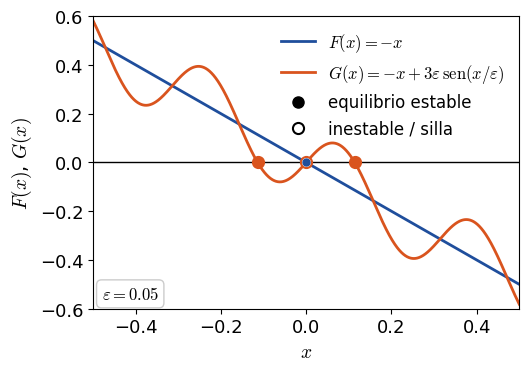

In [2]:
eps = 0.05
F0 = lambda x: -x
G0 = lambda x: -x + 3 * eps * np.sin(x / eps)
x = np.linspace(-0.5, 0.5, 2000)
print(f"||F - G||_0 = {np.abs(F0(x) - G0(x)).max():.3f} = 3 eps;   sup|F' - G'| = {np.abs(3 * np.cos(x / eps)).max():.1f}")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(x, F0(x), color=CICLO[0], lw=2, label=r"$F(x) = -x$")
ax.plot(x, G0(x), color=CICLO[1], lw=2, label=r"$G(x) = -x + 3\varepsilon\,\mathrm{sen}(x/\varepsilon)$")
ax.axhline(0, color="black", lw=1)
# equilibrios de G: ceros por cambio de signo; estables si G' < 0
ceros = [xa - G0(xa) * (xb - xa) / (G0(xb) - G0(xa)) for xa, xb in zip(x[:-1], x[1:]) if G0(xa) * G0(xb) < 0]
for e in ceros:
    dG = (G0(e + 1e-6) - G0(e - 1e-6)) / 2e-6
    ax.plot(e, 0, "o", ms=8, color=CICLO[1] if dG < 0 else "white", mec=CICLO[1], mew=1.5, zorder=6)
ax.plot(0, 0, "o", ms=5, color=CICLO[0], zorder=7)
print("equilibrios de G:", np.round(ceros, 3), " (el de F es sólo x = 0)")
ax.set_xlabel("$x$"); ax.set_ylabel("$F(x)$, $G(x)$"); ax.set_xlim(-0.5, 0.5); ax.set_ylim(-0.6, 0.6)
ax.legend(loc="upper right", handles=ax.get_legend_handles_labels()[0] + LEYENDA_EQ, fontsize=12)
estilo.parametros(ax, rf"$\varepsilon = {eps}$", loc="lower left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "c0-cerca")

## 8.3 Bifurcaciones en dimensión uno

Los tres casos canónicos: silla-nodo $\dot x = \mu - x^2$, transcrítica $\dot x = \mu x - x^2$ y horquilla $\dot x = \mu x - x^3$. Para cada uno hacemos dos figuras: los **diagramas de fase** para $\mu<0$, $\mu=0$ y $\mu>0$ (el gráfico de $f(\cdot,\mu)$ y la recta de fase con `fases.recta_de_fase`; un equilibrio es estable si $f$ pasa de positiva a negativa) y el **diagrama de bifurcación** en el plano $(\mu, x)$: las curvas de equilibrios $f(x,\mu)=0$, en trazo lleno donde $f_x<0$ (estable) y a trazos donde $f_x>0$ (inestable), con la recta de fase vertical dibujada para tres valores de $\mu$.

En $\mu = 0$ el equilibrio $x^*=0$ no es hiperbólico ($f_x(0,0) = 0$); en la silla-nodo y la transcrítica es *semiestable* (atrae de un lado y repele del otro) y lo dibujamos vacío.

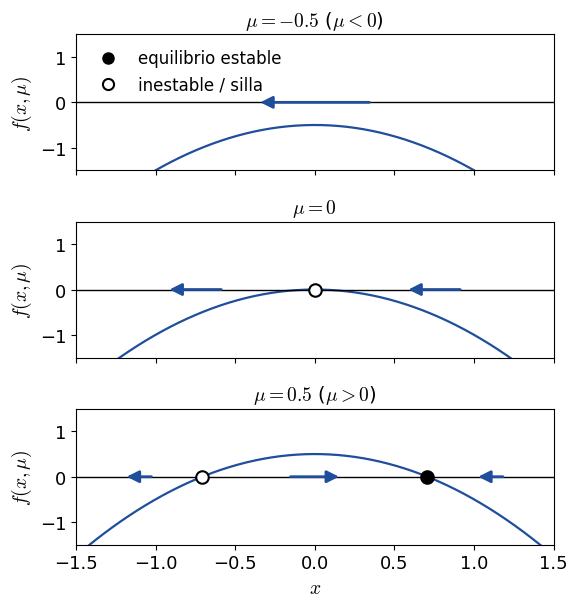

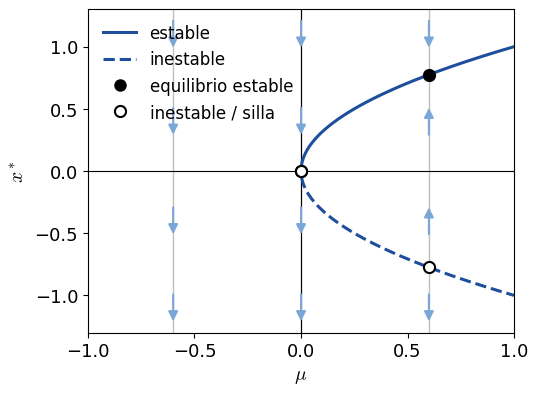

In [3]:
def diagramas_de_fase_1d(f, equilibrios, mus, nombre, xlim=(-1.5, 1.5)):
    '''Tres rectas de fase (una por valor de mu) con el gráfico de f(x, mu) encima.
    `equilibrios(mu)` devuelve la lista de equilibrios reales para ese mu.'''
    fig, axs = plt.subplots(3, 1, figsize=(6, 6.3), sharex=True)
    for ax, mu in zip(axs, mus):
        fases.recta_de_fase(lambda x: f(x, mu), *xlim, ax=ax, nombre="x", equilibrios=equilibrios(mu))
        ax.set_ylabel(rf"$f(x, \mu)$"); ax.set_ylim(-1.5, 1.5)
        ax.set_title(rf"$\mu = {mu:g}$" + ("" if mu == 0 else rf" ($\mu {'<' if mu < 0 else '>'} 0$)"))
        ax.set_xlabel("")
    axs[-1].set_xlabel("$x$")
    axs[0].legend(handles=LEYENDA_EQ, loc="upper left", fontsize=12)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, nombre)
    return fig


def diagrama_bifurcacion_1d(f, ramas, nombre, mus_fase=(-0.6, 0.0, 0.6), xlim=(-1.3, 1.3), mulim=(-1, 1)):
    '''Diagrama de bifurcación en el plano (mu, x). `ramas` es una lista de curvas (mu_k, x_k) de equilibrios;
    cada una se dibuja llena donde f_x < 0 y a trazos donde f_x > 0. En `mus_fase` se dibuja la recta de fase vertical.'''
    fig, ax = plt.subplots(figsize=(5.5, 4.2))
    h = 1e-6
    for mu, xs in ramas:
        fx = (f(xs + h, mu) - f(xs - h, mu)) / (2 * h)
        ax.plot(mu, np.where(fx < 0, xs, np.nan), color=COLORES["traj"], lw=2.2)
        ax.plot(mu, np.where(fx > 0, xs, np.nan), color=COLORES["traj"], lw=2.2, ls="--")
    for mu in mus_fase:
        ax.axvline(mu, color="0.75", lw=1, zorder=0)
        for x0 in (-1.1, -0.4, 0.4, 1.1):        # sentido del movimiento sobre la recta de fase vertical
            s = np.sign(f(x0, mu))
            if s != 0:
                ax.annotate("", xy=(mu, x0 + 0.13 * s), xytext=(mu, x0 - 0.13 * s), arrowprops=dict(arrowstyle="-|>", color=COLORES["traj2"], lw=1.5, mutation_scale=14))
        for mu_r, xs in ramas:                   # equilibrios sobre esa recta
            k = np.argmin(np.abs(mu_r - mu))
            if abs(mu_r[k] - mu) < 1e-6 and np.isfinite(xs[k]):
                fx = (f(xs[k] + h, mu) - f(xs[k] - h, mu)) / (2 * h)
                ax.plot(mu, xs[k], "o", ms=8, color="black" if fx < 0 else "white", mec="black", mew=1.5, zorder=6)
    ax.axhline(0, color="black", lw=0.8, zorder=0); ax.axvline(0, color="black", lw=0.8, zorder=0)
    ax.set_xlim(*mulim); ax.set_ylim(*xlim); ax.set_xlabel(r"$\mu$"); ax.set_ylabel("$x^*$")
    ax.legend(handles=[Line2D([], [], color=COLORES["traj"], lw=2.2, label="estable"), Line2D([], [], color=COLORES["traj"], lw=2.2, ls="--", label="inestable")] + LEYENDA_EQ,
              loc="upper left", fontsize=12)
    if GUARDAR: estilo.guardar(fig, nombre)
    return fig


mu_g = np.linspace(-1, 1, 801)           # grilla de mu para las ramas (incluye exactamente -0.6, 0 y 0.6)
mu_p = mu_g[mu_g >= 0]
mus = (-0.5, 0.0, 0.5)

# Silla-nodo: x' = mu - x^2. Figuras 'saddle-node' y 'diagrama-saddle-node'
f_sn = lambda x, mu: mu - x**2
diagramas_de_fase_1d(f_sn, lambda mu: [0.0] if mu == 0 else ([-np.sqrt(mu), np.sqrt(mu)] if mu > 0 else []), mus, "saddle-node")
diagrama_bifurcacion_1d(f_sn, [(mu_p, np.sqrt(mu_p)), (mu_p, -np.sqrt(mu_p))], "diagrama-saddle-node");

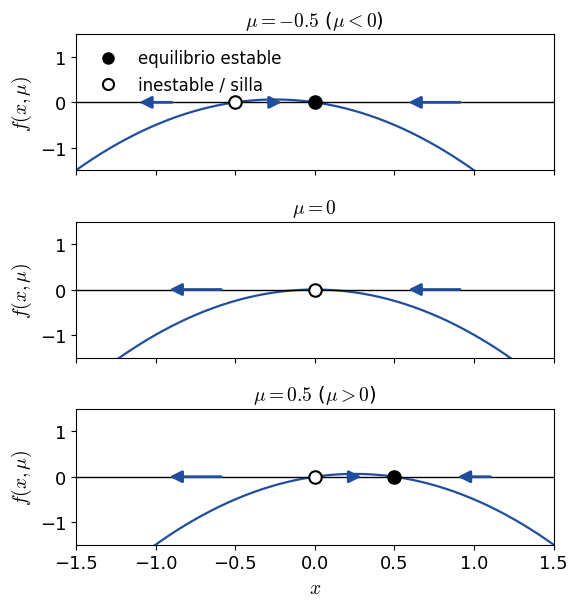

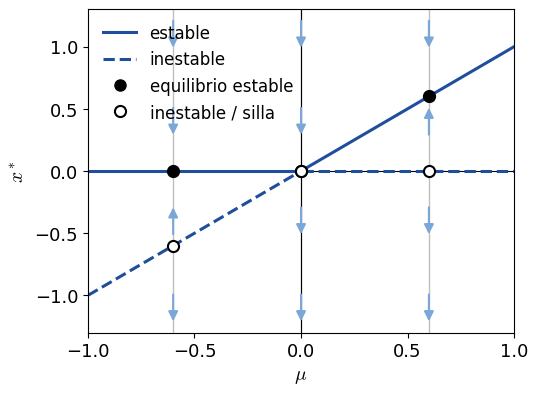

In [4]:
# Transcrítica: x' = mu x - x^2. Figuras 'transcritica' y 'diagrama-transcritica'
f_tc = lambda x, mu: mu * x - x**2
diagramas_de_fase_1d(f_tc, lambda mu: sorted({0.0, mu}), mus, "transcritica")
diagrama_bifurcacion_1d(f_tc, [(mu_g, 0 * mu_g), (mu_g, mu_g)], "diagrama-transcritica");

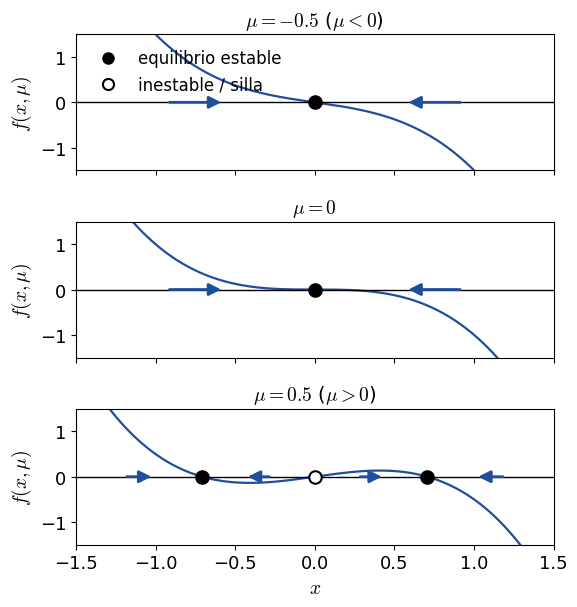

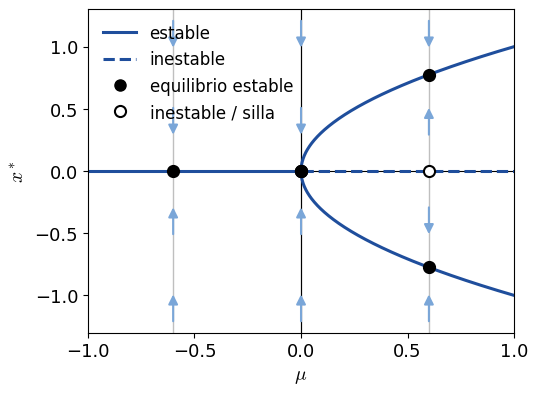

In [5]:
# Horquilla: x' = mu x - x^3. Figuras 'pitchfork' y 'diagrama-pitchfork'
f_pf = lambda x, mu: mu * x - x**3
diagramas_de_fase_1d(f_pf, lambda mu: [0.0] if mu <= 0 else [-np.sqrt(mu), 0.0, np.sqrt(mu)], mus, "pitchfork")
diagrama_bifurcacion_1d(f_pf, [(mu_g, 0 * mu_g), (mu_p, np.sqrt(mu_p)), (mu_p, -np.sqrt(mu_p))], "diagrama-pitchfork");

## 8.4 Bifurcaciones en dimensión dos: un sistema de control genético

$$\dot x = -ax + y,\qquad \dot y = \frac{x^2}{1+x^2} - by,\qquad a, b>0.$$

Nulclinas: $y = ax$ y $y = \dfrac{x^2}{b(1+x^2)}$. Los equilibrios no triviales cumplen $x = ab(1+x^2)$, es decir $ab\,x^2 - x + ab = 0$, que tiene dos raíces reales si $2ab<1$, una doble si $2ab = 1$ y ninguna si $2ab>1$. Con $b$ fijo, el valor crítico es $a_c = \dfrac{1}{2b}$.

**Figura `nulclinas-bif`**: las nulclinas para $b = 1$ y $a = 0.4,\ 0.5,\ 0.6$ (es decir $2ab<1$, $=1$, $>1$), ahora etiquetadas.

b = 1.0: último a con dos equilibrios no triviales = 0.4999;  a_c = 1/(2b) = 0.5
a = 0.4:  (0.00, 0.00) nodo estable; (0.50, 0.20) silla; (2.00, 0.80) nodo estable
a = 0.5:  (0.00, 0.00) nodo estable; (1.00, 0.50) degenerado
a = 0.6:  (0.00, 0.00) nodo estable


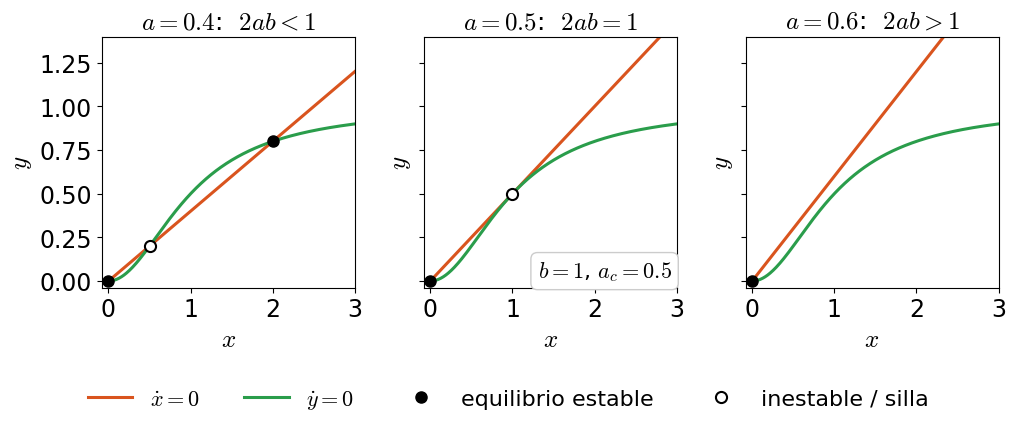

In [6]:
def genetico(t, X, a, b):
    x, y = X
    return [-a * x + y, x**2 / (1 + x**2) - b * y]

def equilibrios_genetico(a, b):
    '''(0,0) y las raíces reales de ab x^2 - x + ab = 0 (con y = ax), clasificadas con el jacobiano.'''
    xs = [0.0]
    disc = 1 - 4 * a**2 * b**2
    if disc >= 0:
        xs += sorted({(1 - np.sqrt(disc)) / (2 * a * b), (1 + np.sqrt(disc)) / (2 * a * b)})
    return [(x, a * x, fases.clasificar(fases.jacobiano(genetico, [x, a * x], args=(a, b)))) for x in xs]

def nulclinas_genetico(ax, a, b, xmax=3.0):
    xx = np.linspace(0, xmax, 400)
    ax.plot(xx, a * xx, color=COLORES["nul_h"], lw=2.2, label=r"$\dot x = 0$")
    ax.plot(xx, xx**2 / (b * (1 + xx**2)), color=COLORES["nul_p"], lw=2.2, label=r"$\dot y = 0$")
    ax.set_xlabel("$x$"); ax.set_ylabel("$y$")

# Verificación de a_c: el valor de a en que las dos raíces se juntan, comparado con la fórmula 1/(2b)
b = 1.0
a_c = 1 / (2 * b)
aa = np.linspace(0.3, 0.7, 4001)
n_eq = np.array([len(equilibrios_genetico(a, b)) - 1 for a in aa])
print(f"b = {b}: último a con dos equilibrios no triviales = {aa[n_eq == 2].max():.4f};  a_c = 1/(2b) = {a_c}")

with fuente(18):
    fig, axs = plt.subplots(1, 3, figsize=(10.5, 4.4), sharey=True)
    for ax, a in zip(axs, [0.4, 0.5, 0.6]):
        nulclinas_genetico(ax, a, b)
        eqs = equilibrios_genetico(a, b)
        fases.marcar_equilibrios(ax, [(x, y, "estable" if tipo.endswith(" estable") else "inestable") for x, y, tipo in eqs])
        signo = "<" if a < a_c else ("=" if a == a_c else ">")
        ax.set_title(rf"$a = {a}$:  $2ab {signo} 1$")
        ax.set_xlim(-0.08, 3); ax.set_ylim(-0.04, 1.4); ax.set_xticks([0, 1, 2, 3])
        print(f"a = {a}: ", "; ".join(f"({x:.2f}, {y:.2f}) {tipo}" for x, y, tipo in eqs))
    fig.legend(handles=axs[0].get_legend_handles_labels()[0] + LEYENDA_EQ, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.02))
    estilo.parametros(axs[1], rf"$b = {b:g}$, $a_c = {a_c}$", loc="lower right", fontsize=16)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    if GUARDAR: estilo.guardar(fig, "nulclinas-bif")

**Figura `ej-bif1`** ($a<a_c$): nulclinas, equilibrios y campo de direcciones. El texto muestra que $\operatorname{tr} DF = -(a+b) < 0$ siempre, así que cada equilibrio es una silla ($\Delta<0$) o un sumidero ($\Delta>0$), y que $\Delta = ab\,\frac{(x^*)^2-1}{1+(x^*)^2}$ en los no triviales: el que tiene $x_1^*<1$ es una silla y el que tiene $x_2^*>1$ un nodo estable; el origen es un nodo estable. Corrección: el origen ahora está marcado (y clasificado).

(0.000, 0.000): nodo estable   tr = -1.400 (texto: -(a+b) = -1.400),  det = +0.4000 (texto: ab = +0.4000)
(0.500, 0.200): silla          tr = -1.400 (texto: -(a+b) = -1.400),  det = -0.2400 (texto: ab(x*^2-1)/(1+x*^2) = -0.2400)
(2.000, 0.800): nodo estable   tr = -1.400 (texto: -(a+b) = -1.400),  det = +0.2400 (texto: ab(x*^2-1)/(1+x*^2) = +0.2400)


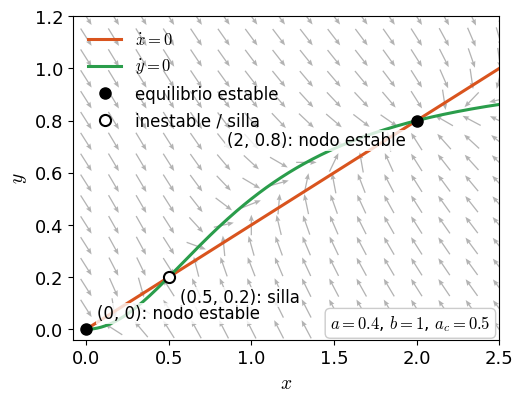

In [7]:
a = 0.4
eqs = equilibrios_genetico(a, b)
for x, y, tipo in eqs:
    J = fases.jacobiano(genetico, [x, y], args=(a, b))
    print(f"({x:.3f}, {y:.3f}): {tipo:14s} tr = {np.trace(J):+.3f} (texto: -(a+b) = {-(a+b):+.3f}),  det = {np.linalg.det(J):+.4f}"
          + (f" (texto: ab(x*^2-1)/(1+x*^2) = {a * b * (x**2 - 1) / (1 + x**2):+.4f})" if x > 0 else f" (texto: ab = {a * b:+.4f})"))
tipos = [(x, y, "estable" if tipo.endswith(" estable") else "silla") for x, y, tipo in eqs]

fig, ax = plt.subplots(figsize=(5.5, 4.2))
fases.campo(genetico, (0, 2.5), (0, 1.2), ax=ax, n=16, args=(a, b))
nulclinas_genetico(ax, a, b)
fases.marcar_equilibrios(ax, tipos)
for x, y, tipo in eqs:
    ax.annotate(f"({x:.2g}, {y:.2g}): {tipo}", (x, y), (8 if x < 1 else -8, 8 if x == 0 else -18), textcoords="offset points", ha="left" if x < 1 else "right", fontsize=12, bbox=dict(fc="white", ec="none", alpha=0.8, pad=1))
ax.set_xlim(-0.08, 2.5); ax.set_ylim(-0.04, 1.2)
ax.legend(handles=ax.get_legend_handles_labels()[0] + LEYENDA_EQ, loc="upper left", fontsize=12)
estilo.parametros(ax, rf"$a = {a}$, $b = {b:g}$, $a_c = {a_c}$", loc="lower right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "ej-bif1")

**Figura `ej-bif1-fases`**: diagrama de fases para $a<a_c$. Correcciones: el origen está marcado, la silla se dibuja vacía y la leyenda explica la convención (lleno = estable, vacío = inestable/silla). Agregamos las variedades de la silla (integrando desde ella hacia adelante y hacia atrás en las direcciones de sus autovectores): la variedad estable separa la cuenca del origen (se apaga la expresión del gen) de la cuenca del otro nodo (expresión sostenida).

autovalores de la silla: [ 0.1544 -1.5544]


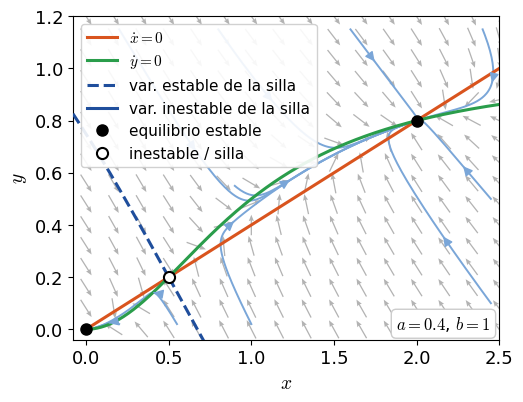

In [8]:
def variedades_silla(F, Xs, ax, args=(), T=30, color=None, **kw):
    '''Variedades estable (integrando hacia atrás) e inestable (hacia adelante) de la silla Xs.'''
    color = color or COLORES["traj"]
    J = fases.jacobiano(F, Xs, args=args)
    lam, V = np.linalg.eig(J)
    for k in range(2):
        v = np.real(V[:, k]) * 1e-4
        for s in (+1, -1):
            sol = solve_ivp(F, (0, T if lam[k] > 0 else -T), np.asarray(Xs) + s * v, args=args, rtol=1e-9, atol=1e-12, max_step=T / 800)
            ax.plot(sol.y[0], sol.y[1], color=color, lw=2.2, ls="-" if lam[k] > 0 else "--", zorder=4, **kw)
    return lam

fig, ax = plt.subplots(figsize=(5.5, 4.2))
inicios = [(0.2, 1.15), (0.8, 1.15), (1.6, 1.15), (2.4, 1.15), (2.45, 0.5), (2.45, 0.1), (1.0, 0.02), (0.55, 0.02), (0.9, 0.55), (0.2, 0.02)]
fases.retrato(genetico, (0, 2.5), (0, 1.2), inicios, T=25, ax=ax, args=(a, b), n_campo=16, color=COLORES["traj2"], lw=1.4, pos_flecha=0.3)
nulclinas_genetico(ax, a, b)
silla = [e for e in eqs if e[2] == "silla"][0]
lam = variedades_silla(genetico, silla[:2], ax, args=(a, b))
fases.marcar_equilibrios(ax, tipos)
ax.set_xlim(-0.08, 2.5); ax.set_ylim(-0.04, 1.2)
ax.legend(handles=ax.get_legend_handles_labels()[0] + [Line2D([], [], color=COLORES["traj"], lw=2.2, ls="--", label="var. estable de la silla"),
                                                        Line2D([], [], color=COLORES["traj"], lw=2.2, label="var. inestable de la silla")] + LEYENDA_EQ, loc="upper left", fontsize=11, frameon=True, framealpha=0.9)
estilo.parametros(ax, rf"$a = {a}$, $b = {b:g}$", loc="lower right", fontsize=12)
print("autovalores de la silla:", np.round(lam, 4))
if GUARDAR: estilo.guardar(fig, "ej-bif1-fases")

**Figura `diagrama-ej-bif1`**: coordenada $x$ de los equilibrios en función de $a$, con $b$ fijo. Las dos ramas no triviales $x^*_{1,2}(a) = \dfrac{1 \mp \sqrt{1-4a^2b^2}}{2ab}$ se juntan en $a = a_c$ (donde $x^* = 1$, justamente el valor en que $\Delta$ cambia de signo) y desaparecen: es la forma de la silla-nodo de la Figura `diagrama-saddle-node`, girada. Corrección: la rama trivial $x^* = 0$ (nodo estable para todo $a$) es ahora visible.

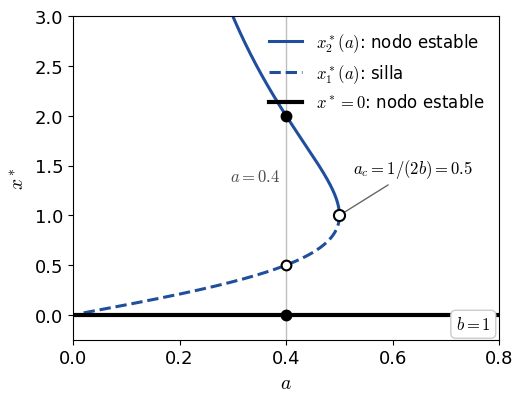

In [9]:
aa = np.linspace(0.02, a_c, 600)
disc = np.sqrt(np.clip(1 - 4 * aa**2 * b**2, 0, None))
x1, x2 = (1 - disc) / (2 * aa * b), (1 + disc) / (2 * aa * b)
fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot(aa, x2, color=COLORES["traj"], lw=2.2, label="$x_2^*(a)$: nodo estable")
ax.plot(aa, x1, color=COLORES["traj"], lw=2.2, ls="--", label="$x_1^*(a)$: silla")
ax.plot([0, 0.8], [0, 0], color="black", lw=3, label="$x^* = 0$: nodo estable", zorder=3)
ax.plot(a_c, 1, "o", ms=8, color="white", mec="black", mew=1.5, zorder=6)
ax.annotate(rf"$a_c = 1/(2b) = {a_c}$", (a_c, 1), (10, 30), textcoords="offset points", ha="left", fontsize=12, arrowprops=dict(arrowstyle="-", color="0.4"))
for x, y, tipo in eqs:      # los tres equilibrios de las figuras anteriores (a = 0.4)
    ax.plot(a, x, "o", ms=7, color="black" if tipo.endswith(" estable") else "white", mec="black", mew=1.5, zorder=6)
ax.axvline(a, color="0.75", lw=1, zorder=0); ax.text(a - 0.01, 1.3, rf"$a = {a}$", ha="right", va="bottom", fontsize=12, color="0.3")
ax.set_xlim(0, 0.8); ax.set_ylim(-0.25, 3); ax.set_xlabel("$a$"); ax.set_ylabel("$x^*$")
ax.legend(loc="upper right", fontsize=12)
estilo.parametros(ax, rf"$b = {b:g}$", loc="lower right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "diagrama-ej-bif1")

## 8.5 Bifurcación de Hopf

El Teorema de Hopf trata un equilibrio cuyo jacobiano tiene autovalores $\alpha(\mu)\pm i\omega(\mu)$ con $\alpha(0) = 0$, $\alpha'(0)>0$. El modelo más simple con esta estructura, en coordenadas polares, es
$$\dot r = \mu r + \ell\, r^3,\qquad \dot\theta = \omega,$$
(que en cartesianas es $\dot x = \mu x - \omega y + \ell x(x^2+y^2)$, $\dot y = \omega x + \mu y + \ell y(x^2+y^2)$). El signo de $\ell$ hace el papel del primer coeficiente de Lyapunov $\ell_1$:

* $\ell<0$ (**supercrítica**): para $\mu>0$ hay una órbita periódica $r = \sqrt{\mu/|\ell|}$, ciclo límite estable, que nace del origen con amplitud $\propto\sqrt\mu$; para $\mu\le 0$ no hay órbitas periódicas.
* $\ell>0$ (**subcrítica**): para $\mu<0$ hay una órbita periódica $r = \sqrt{-\mu/\ell}$, ciclo límite inestable; para $\mu\ge 0$ no hay.

*Figura nueva `hopf-diagrama`* (la figura pendiente del texto): arriba, la amplitud de la órbita periódica en función de $\mu$ en los dos casos (con $|\ell| = 1$), en trazo lleno si es estable y a trazos si es inestable, junto con la estabilidad del origen; abajo, tres retratos de fase de la forma normal supercrítica para $\mu<0$, $\mu = 0$ y $\mu>0$.

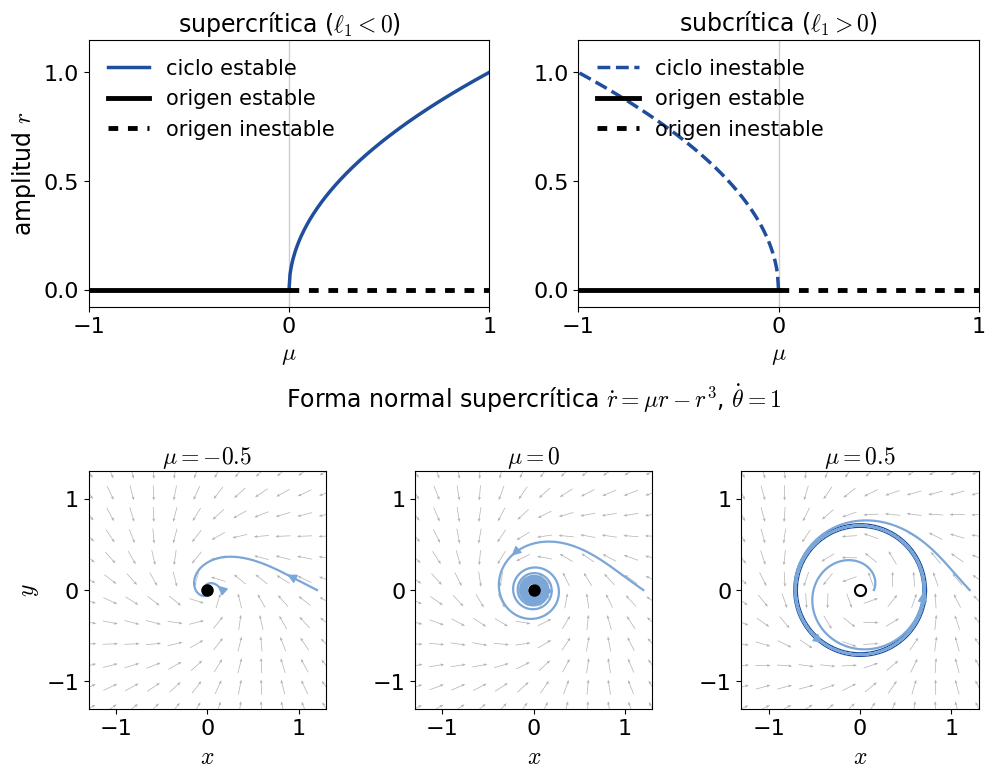

In [10]:
def hopf(t, X, mu, ell, w=1.0):
    x, y = X
    r2 = x**2 + y**2
    return [mu * x - w * y + ell * x * r2, w * x + mu * y + ell * y * r2]

with fuente(17):
    fig = plt.figure(figsize=(10, 8))
    gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.15], hspace=0.45, wspace=1.2, left=0.09, right=0.98, top=0.95, bottom=0.07)
    mm = np.linspace(0, 1, 200)
    for j, (ell, titulo) in enumerate([(-1, r"supercrítica ($\ell_1<0$)"), (+1, r"subcrítica ($\ell_1>0$)")]):
        ax = fig.add_subplot(gs[0, 3 * j:3 * j + 3])
        if ell < 0:
            ax.plot(mm, np.sqrt(mm), color=COLORES["traj"], lw=2.5, label=r"ciclo estable")
        else:
            ax.plot(-mm, np.sqrt(mm), color=COLORES["traj"], lw=2.5, ls="--", label=r"ciclo inestable")
        ax.plot([-1, 0], [0, 0], color="black", lw=3.5, label="origen estable"); ax.plot([0, 1], [0, 0], color="black", lw=3.5, ls=(0, (2, 2)), label="origen inestable")
        ax.axvline(0, color="0.8", lw=1, zorder=0)
        ax.set_xlim(-1, 1); ax.set_ylim(-0.08, 1.15); ax.set_xlabel(r"$\mu$"); ax.set_xticks([-1, 0, 1]); ax.set_yticks([0, 0.5, 1])
        if j == 0: ax.set_ylabel("amplitud $r$")
        ax.set_title(titulo); ax.legend(loc="upper left")

    for j, mu in enumerate([-0.5, 0.0, 0.5]):
        ax = fig.add_subplot(gs[1, 2 * j:2 * j + 2])
        R = 1.3
        fases.campo(hopf, (-R, R), (-R, R), ax=ax, n=12, args=(mu, -1.0))
        if mu > 0:
            th = np.linspace(0, 2 * np.pi, 300); ax.plot(np.sqrt(mu) * np.cos(th), np.sqrt(mu) * np.sin(th), color=COLORES["traj"], lw=3.5)
        for X0 in [(1.2, 0.0), (0.15, 0.0)]:
            fases.trayectoria(hopf, X0, 60 if mu == 0 else 30, ax=ax, args=(mu, -1.0), color=COLORES["traj2"], lw=1.6, pos_flecha=0.15)
        fases.marcar_equilibrios(ax, [(0, 0, "estable" if mu <= 0 else "inestable")])
        ax.set_xlim(-R, R); ax.set_ylim(-R, R); ax.set_aspect("equal"); ax.set_xlabel("$x$"); ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
        if j == 0: ax.set_ylabel("$y$")
        ax.set_title(rf"$\mu = {mu:g}$")
    fig.text(0.535, 0.49, r"Forma normal supercrítica $\dot r = \mu r - r^3$, $\dot\theta = 1$", ha="center", fontsize=17)
    if GUARDAR: estilo.guardar(fig, "hopf-diagrama")

### Hopf genérica frente a van der Pol (el caso degenerado)

Para van der Pol, $\dot x = y,\ \dot y = -x - \lambda(x^2-1)y$, el origen cumple las hipótesis del teorema con $\mu = \lambda$ ($\alpha(\lambda) = \lambda/2$, $\omega(0) = 1$). Pero en $\lambda = 0$ el sistema es exactamente lineal (un centro): $\ell_1 = 0$, es el **caso degenerado**, y el ciclo aparece "de golpe" con amplitud finita: la ecuación promediada $\dot{\bar r} = \frac{\lambda}{8}\bar r(4-\bar r^2)$ da radio $\approx 2$ para todo $\lambda>0$ chico. En la familia $\ddot x + (x^2-\mu)\dot x + x = 0$ (es decir $\dot y = -x - (x^2-\mu)y$) los dos papeles de $\lambda$ se desacoplan: el promedio da $\dot{\bar r} = \frac{\mu}{2}\bar r - \frac18\bar r^3$ y el ciclo nace en $\mu = 0$ con amplitud $2\sqrt\mu$, una Hopf supercrítica genérica.

El coeficiente del término cúbico de la ecuación promediada juega el papel de $\ell_1$: vale $-\tfrac18$ para la familia genérica (supercrítica) y $-\tfrac{\lambda}{8}$ para van der Pol, que se anula en el punto de bifurcación (degenerada). Medimos numéricamente la amplitud del ciclo en los dos casos (*figura nueva `hopf-generica-vs-vdp`*).

 mu (o lambda)  genérica  2 sqrt(mu) err. rel. | van der Pol |amp - 2|
          0.05    0.4472      0.4472    0.0000 |      2.0000    0.0000
          0.10    0.6325      0.6325    0.0001 |      2.0001    0.0001
          0.20    0.8946      0.8944    0.0002 |      2.0004    0.0004
          0.30    1.0960      1.0954    0.0005 |      2.0009    0.0009
          0.50    1.4160      1.4142    0.0012 |      2.0025    0.0025
          0.70    1.6772      1.6733    0.0023 |      2.0047    0.0047
          1.00    2.0086      2.0000    0.0043 |      2.0086    0.0086


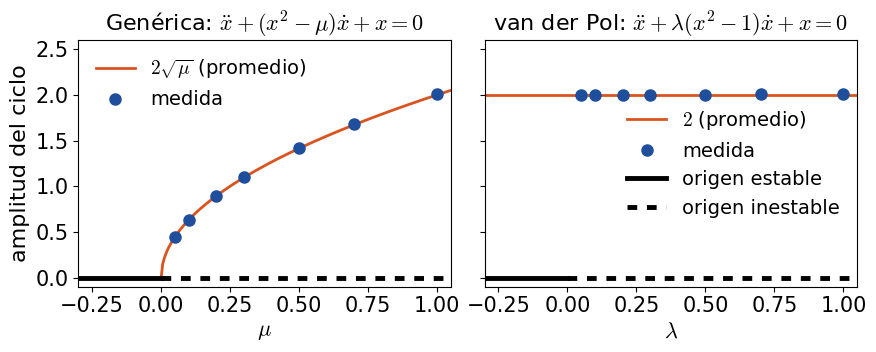

In [11]:
def vdP(t, X, lam):
    x, y = X
    return [y, -x - lam * (x**2 - 1) * y]

def generica(t, X, mu):
    x, y = X
    return [y, -x - (x**2 - mu) * y]

def amplitud_ciclo(F, args, X0=(1.0, 0.0), T=400):
    '''Amplitud (max de |x|) en el último 15% de una integración larga, y su variación respecto del tramo anterior.'''
    t, (x, y) = simular(F, X0, T, args=args, n=int(T * 25))
    n = len(x); a2, a1 = np.abs(x[int(0.85 * n):]).max(), np.abs(x[int(0.7 * n):int(0.85 * n)]).max()
    return a2, abs(a2 - a1)

params = np.array([0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0])
amp_gen = np.array([amplitud_ciclo(generica, (mu,), T=max(300, 40 / mu))[0] for mu in params])
amp_vdp = np.array([amplitud_ciclo(vdP, (lam,), T=max(300, 40 / lam))[0] for lam in params])
print(f"{'mu (o lambda)':>14} {'genérica':>9} {'2 sqrt(mu)':>11} {'err. rel.':>9} | {'van der Pol':>11} {'|amp - 2|':>9}")
for p, ag, av in zip(params, amp_gen, amp_vdp):
    print(f"{p:14.2f} {ag:9.4f} {2 * np.sqrt(p):11.4f} {abs(ag / (2 * np.sqrt(p)) - 1):9.4f} | {av:11.4f} {abs(av - 2):9.4f}")

with fuente(16):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
    mm = np.linspace(0, 1.05, 200)
    ax1.plot(mm, 2 * np.sqrt(mm), color=COLORES["modelo"], lw=2, label=r"$2\sqrt{\mu}$ (promedio)")
    ax1.plot(params, amp_gen, "o", color=COLORES["dato"], ms=8, label="medida")
    ax1.plot([-0.3, 0], [0, 0], color="black", lw=3.5); ax1.plot([0, 1.05], [0, 0], color="black", lw=3.5, ls=(0, (2, 2)))
    ax1.set_xlim(-0.3, 1.05); ax1.set_ylim(-0.1, 2.6); ax1.set_xlabel(r"$\mu$"); ax1.set_ylabel("amplitud del ciclo")
    ax1.set_title(r"Genérica: $\ddot x + (x^2-\mu)\dot x + x = 0$"); ax1.legend(loc="upper left")
    ax2.axhline(2, color=COLORES["modelo"], lw=2, label=r"$2$ (promedio)")
    ax2.plot(params, amp_vdp, "o", color=COLORES["dato"], ms=8, label="medida")
    ax2.plot([-0.3, 0], [0, 0], color="black", lw=3.5, label="origen estable"); ax2.plot([0, 1.05], [0, 0], color="black", lw=3.5, ls=(0, (2, 2)), label="origen inestable")
    ax2.set_xlim(-0.3, 1.05); ax2.set_xlabel(r"$\lambda$")
    ax2.set_title(r"van der Pol: $\ddot x + \lambda(x^2-1)\dot x + x = 0$"); ax2.legend(loc="center right")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "hopf-generica-vs-vdp")

**El modelo de bacterias** (Ejemplo del texto): en el equilibrio $(1,1)$ del modelo de bacterias la traza es $\dfrac{k-2-\beta}{k(1+\beta)}$, que se anula en $k_c = 2+\beta$ con derivada positiva, y cerca de ahí los autovalores son complejos: hipótesis de Hopf con $\mu = k-k_c$. Verificamos con el jacobiano numérico y medimos la amplitud del ciclo justo después de $k_c$: crece como $\sqrt{k-k_c}$ (supercrítica, no degenerada).

In [12]:
def bacterias(t, X, k, beta, gamma):
    h, p = X
    ah, ap = (1 - 1 / k) * (beta + 1), gamma * (beta + 1)
    return [h * (1 - h / k) - ah * p * h / (beta + h), ap * p * h / (beta + h) - gamma * p]

beta, gamma = 1.0, 0.5
k_c = 2 + beta
for k in [k_c - 0.2, k_c, k_c + 0.2]:
    J = fases.jacobiano(bacterias, [1, 1], args=(k, beta, gamma))
    lam = np.linalg.eigvals(J)
    print(f"k = {k:.1f}: autovalores {np.round(lam, 4)},  alpha = {lam[0].real:+.4f} (texto: tr/2 = {(k - 2 - beta) / (2 * k * (1 + beta)):+.4f}),  omega = {abs(lam[0].imag):.4f}")
dk = np.array([0.05, 0.1, 0.2, 0.4])
amp = np.array([amplitud_ciclo(bacterias, (k_c + d, beta, gamma), X0=(1.1, 1.0), T=max(600, 60 / d))[0] - 1 for d in dk])
print("k - k_c:", dk, "\namplitud de h - 1:", np.round(amp, 4), "\namplitud / sqrt(k - k_c):", np.round(amp / np.sqrt(dk), 4), " (aprox. constante: crece como sqrt(k - k_c))")

k = 2.8: autovalores [-0.0179+0.4005j -0.0179-0.4005j],  alpha = -0.0179 (texto: tr/2 = -0.0179),  omega = 0.4005
k = 3.0: autovalores [0.+0.4082j 0.-0.4082j],  alpha = +0.0000 (texto: tr/2 = +0.0000),  omega = 0.4082
k = 3.2: autovalores [0.0156+0.4143j 0.0156-0.4143j],  alpha = +0.0156 (texto: tr/2 = +0.0156),  omega = 0.4143


k - k_c: [0.05 0.1  0.2  0.4 ] 
amplitud de h - 1: [0.3508 0.5173 0.776  1.1871] 
amplitud / sqrt(k - k_c): [1.569  1.6358 1.7353 1.8769]  (aprox. constante: crece como sqrt(k - k_c))


## 8.6 Volvemos a la epidemia: SIR con nacimientos y muertes

$$\dot s = \mu(1-s) - \beta s i,\qquad \dot i = \beta s i - (\gamma+\mu)\, i,\qquad R_0 = \frac{\beta}{\gamma+\mu}.$$

Equilibrios: el libre de enfermedad $(1, 0)$, con autovalores $-\mu$ y $(\gamma+\mu)(R_0-1)$ (nodo estable si $R_0<1$, silla si $R_0>1$), y el endémico $(s^*, i^*) = \bigl(1/R_0,\ \tfrac{\mu}{\beta}(R_0-1)\bigr)$, con $\operatorname{tr} = -\mu R_0$ y $\det = \mu(\gamma+\mu)(R_0-1)$: asintóticamente estable si $R_0>1$, foco o nodo según el signo de $\operatorname{tr}^2 - 4\det$. Al cruzar $R_0 = 1$ los dos equilibrios intercambian estabilidad: bifurcación transcrítica, con $R_0 - 1$ en el papel de $\mu$ e $i$ en el de $x$.

*Figura nueva `sir-demografia`*: (a) diagrama de bifurcación $i^*$ vs $R_0$ (tiempo medido en unidades de $1/\gamma$, es decir $\gamma = 1$; la rama endémica con $i^*<0$ para $R_0<1$ no tiene sentido biológico y se dibuja en gris); (b) una simulación con $R_0>1$: oscilaciones amortiguadas hacia el equilibrio endémico, con el período que predice la linealización.

In [13]:
def SIR_mu(t, X, beta, gamma, mu):
    s, i = X
    return [mu * (1 - s) - beta * s * i, beta * s * i - (gamma + mu) * i]

gamma, mu = 1.0, 0.02
R0_de = lambda beta: beta / (gamma + mu)
endemico = lambda beta: (1 / R0_de(beta), mu / beta * (R0_de(beta) - 1))

# Verificación de lo que afirma el texto sobre los dos equilibrios, para varios R0
print(f"gamma = {gamma}, mu = {mu}")
for beta in [0.5, 0.9, 1.5, 3.0, 8.0]:
    R0 = R0_de(beta)
    J0 = fases.jacobiano(SIR_mu, [1, 0], args=(beta, gamma, mu))
    linea = f"R0 = {R0:5.2f}: (1,0) {fases.clasificar(J0):14s} autovalores {np.round(np.sort(np.linalg.eigvals(J0).real), 3)} (texto: {-mu}, {(gamma + mu) * (R0 - 1):.3f})"
    if R0 > 1:
        s_, i_ = endemico(beta)
        J = fases.jacobiano(SIR_mu, [s_, i_], args=(beta, gamma, mu))
        linea += f" | endémico ({s_:.3f}, {i_:.4f}) {fases.clasificar(J)}, tr = {np.trace(J):+.4f} (texto {-mu * R0:+.4f}), det = {np.linalg.det(J):.4f} (texto {mu * (gamma + mu) * (R0 - 1):.4f})"
    print(linea)

beta = 3.0
R0 = R0_de(beta); s_, i_ = endemico(beta)
J = fases.jacobiano(SIR_mu, [s_, i_], args=(beta, gamma, mu)); lam = np.linalg.eigvals(J)
T_lin = 2 * np.pi / abs(lam[0].imag)
t, (s, i) = simular(SIR_mu, [0.9, 0.01], 400, args=(beta, gamma, mu))
picos = np.where((i[1:-1] > i[:-2]) & (i[1:-1] > i[2:]))[0] + 1
print(f"\nbeta = {beta}, R0 = {R0:.3f}: endémico ({s_:.4f}, {i_:.4f}), autovalores {np.round(lam, 4)} -> {fases.clasificar(J)}")
print(f"período de la linealización 2 pi / Im = {T_lin:.2f};  separación entre picos de i(t): {np.round(np.diff(t[picos]), 2)}")

gamma = 1.0, mu = 0.02
R0 =  0.49: (1,0) nodo estable   autovalores [-0.52 -0.02] (texto: -0.02, -0.520)
R0 =  0.88: (1,0) nodo estable   autovalores [-0.12 -0.02] (texto: -0.02, -0.120)
R0 =  1.47: (1,0) silla          autovalores [-0.02  0.48] (texto: -0.02, 0.480) | endémico (0.680, 0.0063) foco estable, tr = -0.0294 (texto -0.0294), det = 0.0096 (texto 0.0096)
R0 =  2.94: (1,0) silla          autovalores [-0.02  1.98] (texto: -0.02, 1.980) | endémico (0.340, 0.0129) foco estable, tr = -0.0588 (texto -0.0588), det = 0.0396 (texto 0.0396)
R0 =  7.84: (1,0) silla          autovalores [-0.02  6.98] (texto: -0.02, 6.980) | endémico (0.128, 0.0171) foco estable, tr = -0.1569 (texto -0.1569), det = 0.1396 (texto 0.1396)



beta = 3.0, R0 = 2.941: endémico (0.3400, 0.0129), autovalores [-0.0294+0.1968j -0.0294-0.1968j] -> foco estable
período de la linealización 2 pi / Im = 31.92;  separación entre picos de i(t): [40.81 33.01 32.11 31.91 31.91 31.91 31.91 31.91 31.91 31.91 32.01 31.91]


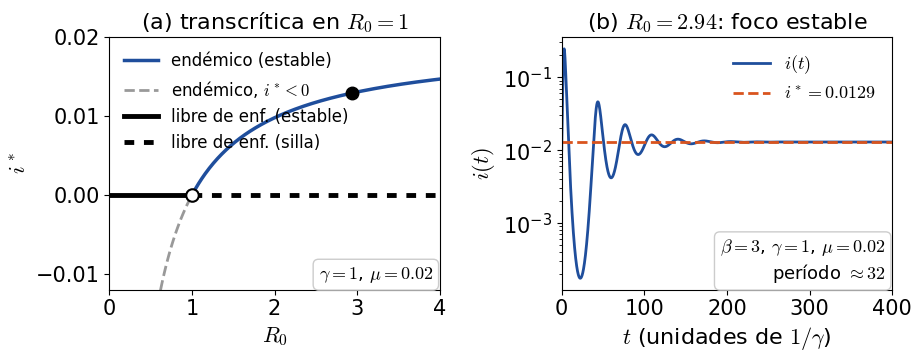

In [14]:
with fuente(16):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 3.9))
    RR = np.linspace(0.01, 4, 400)
    ie = mu * (RR - 1) / (RR * (gamma + mu))                      # i* del endémico como función de R0 (con gamma, mu fijos)
    ax1.plot(RR[RR >= 1], ie[RR >= 1], color=COLORES["traj"], lw=2.5, label="endémico (estable)")
    ax1.plot(RR[(RR < 1) & (RR > 0.3)], ie[(RR < 1) & (RR > 0.3)], color="0.6", lw=2, ls="--", label="endémico, $i^*<0$")
    ax1.plot([0, 1], [0, 0], color="black", lw=3.5, label="libre de enf. (estable)")
    ax1.plot([1, 4], [0, 0], color="black", lw=3.5, ls=(0, (2, 2)), label="libre de enf. (silla)")
    ax1.plot(1, 0, "o", ms=9, color="white", mec="black", mew=1.5, zorder=6)
    ax1.plot(R0, i_, "o", ms=9, color="black", zorder=6)      # el equilibrio del panel (b)
    ax1.set_xlim(0, 4); ax1.set_ylim(-0.012, 0.02); ax1.set_xlabel("$R_0$"); ax1.set_ylabel("$i^*$"); ax1.set_yticks([-0.01, 0, 0.01, 0.02])
    ax1.set_title("(a) transcrítica en $R_0 = 1$"); ax1.legend(loc="upper left", fontsize=12)
    estilo.parametros(ax1, rf"$\gamma = {gamma:g}$, $\mu = {mu}$", loc="lower right", fontsize=13)
    ax2.plot(t, i, color=COLORES["traj"], lw=2, label="$i(t)$")
    ax2.axhline(i_, color=COLORES["nul_h"], ls="--", lw=2, label=rf"$i^* = {i_:.4f}$")
    ax2.set_xlabel(r"$t$ (unidades de $1/\gamma$)"); ax2.set_ylabel("$i(t)$"); ax2.set_yscale("log"); ax2.set_xlim(0, 400)
    ax2.set_title(rf"(b) $R_0 = {R0:.2f}$: {fases.clasificar(J)}"); ax2.legend(loc="upper right", fontsize=13)
    estilo.parametros(ax2, rf"$\beta = {beta:g}$, $\gamma = {gamma:g}$, $\mu = {mu}$" + "\n" + rf"período $\approx {T_lin:.0f}$", loc="lower right", fontsize=13)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "sir-demografia")

## Para experimentar

1. En `diagrama_bifurcacion_1d`, probá con $f(x,\mu) = \mu x + x^3$ (horquilla *subcrítica*) y con $f(x,\mu) = \mu + x^2$: ¿qué cambia en el diagrama? ¿Y con $f(x,\mu) = \mu x + x^3 - x^5$ (biestabilidad e histéresis)?
2. En el sistema genético, cambiá $b$ y verificá que la bifurcación se mueve a $a_c = 1/(2b)$. Con $a$ apenas menor que $a_c$, ¿cuánto tarda una trayectoria en pasar cerca del "fantasma" del equilibrio que desapareció?
3. En `hopf`, poné $\ell = +1$ (subcrítica) y $\mu<0$: comprobá que el ciclo $r = \sqrt{-\mu}$ separa las trayectorias que van al origen de las que escapan. Agregá un término $-r^5$ y mirá qué pasa al cruzar $\mu = 0$.
4. En el SIR con nacimientos, buscá parámetros con los que el equilibrio endémico sea un nodo en lugar de un foco (ayuda: $\operatorname{tr}^2 - 4\det = \mu^2R_0^2 - 4\mu(\gamma+\mu)(R_0-1)$) y compará las simulaciones. ¿Qué pasa con el período de las ondas cuando $\mu \to 0$?